# P1 — Problem Formulation & Exploratory Data Analysis
## Turkey Hourly Electricity Consumption — Day-Ahead Forecasting

**GitHub Repository:** `https://github.com/Beratsri/YZM2011-Project`

---
## 1. Problem Statement

Turkey's electricity producers submit bids to the EPİAŞ day-ahead market before 12:00 each day, committing to hourly generation for the following day. A wrong bid causes imbalance penalties or wasted capacity.

**Prediction target:** `consumption_mwh` at time `t + 24` — Turkey's total hourly electricity consumption (MWh), predicted 24 hours in advance.

**Task type:** Regression — the target is a continuous real number (MWh).

| Stakeholder | Benefit |
|-------------|---------|
| Energy producers | Fewer imbalance penalties |
| Grid operator TEİAŞ | Stable reserve planning |
| End consumers | Lower system costs |

---
## 2. Dataset Description

**Primary — EPİAŞ Transparency Platform:** hourly consumption and production data (`main_data.csv`).

**Secondary — Open-Meteo Archive API:** daily mean temperature, relative humidity, and wind speed for Istanbul, Ankara, and Izmir, averaged as a national proxy.

| Column | Type | Description |
|--------|------|-------------|
| `datetime` | datetime | Timestamp of the hour |
| `consumption_mwh` | float | Total electricity consumed (MWh) — **target** |
| `production_mwh` | float | Total electricity produced (MWh) |
| `temp_avg` | float | Daily mean temperature — 3-city avg (°C) |
| `hum_avg` | float | Daily mean relative humidity — 3-city avg (%) |
| `wind_avg` | float | Daily mean wind speed — 3-city avg (km/h) |

~43 824 rows · January 2021 – January 2026

---
## 3. Data Loading & Initial Inspection

In [138]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import requests
import warnings
import os
from scipy import stats

warnings.filterwarnings('ignore')
os.makedirs('data', exist_ok=True)
os.makedirs('figures', exist_ok=True)
print('Libraries loaded.')

Libraries loaded.


In [139]:
# Load the dataset and set datetime as index
df = pd.read_csv('main_data.csv', index_col=0)
df['datetime'] = pd.to_datetime(df['datetime'])
df = df.set_index('datetime').sort_index()

print('--- head ---')
print(df.head())
print(f'\nShape  : {df.shape}')
print(f'Period : {df.index.min().date()} → {df.index.max().date()}')

--- head ---
                     consumption_mwh  production_mwh
datetime                                            
2021-01-01 00:00:00         29489.46        29488.11
2021-01-01 01:00:00         28067.11        28065.76
2021-01-01 02:00:00         26527.08        26527.08
2021-01-01 03:00:00         25327.19        25327.19
2021-01-01 04:00:00         24719.72        24719.72

Shape  : (43824, 2)
Period : 2021-01-01 → 2025-12-31


In [140]:
# Fetch daily weather data from Open-Meteo API for Istanbul, Ankara, and Izmir
# Average the three cities to get a national proxy
# Map daily values to every hour of that day

# Getting Weather Data from Open-Meteo
# Temperature - Humidity - Wind of 
# Istanbul , Ankara , Izmır

def get_weather(lat, lon, start, end, city):
    resp = requests.get(
        'https://archive-api.open-meteo.com/v1/archive',
        params={
            'latitude': lat, 'longitude': lon,
            'start_date': start, 'end_date': end,
            'daily': 'temperature_2m_mean,relative_humidity_2m_mean,wind_speed_10m_mean',
            'timezone': 'Europe/Istanbul'
        }, timeout=30
    ).json()
    return pd.DataFrame({
        'date': pd.to_datetime(resp['daily']['time']),
        f'temp_{city}': resp['daily']['temperature_2m_mean'],
        f'hum_{city}':  resp['daily']['relative_humidity_2m_mean'],
        f'wind_{city}': resp['daily']['wind_speed_10m_mean'],
    })

START = str(df.index.min().date())
END   = str(df.index.max().date())

w_ist = get_weather(41.01, 28.97, START, END, 'ist')
w_ank = get_weather(39.93, 32.85, START, END, 'ank')
w_izm = get_weather(38.42, 27.14, START, END, 'izm')

weather = w_ist.merge(w_ank, on='date').merge(w_izm, on='date')
weather['temp_avg'] = weather[['temp_ist','temp_ank','temp_izm']].mean(axis=1)
weather['hum_avg']  = weather[['hum_ist','hum_ank','hum_izm']].mean(axis=1)
weather['wind_avg'] = weather[['wind_ist','wind_ank','wind_izm']].mean(axis=1)

df['temp_avg'] = df.index.normalize().map(weather.set_index('date')['temp_avg'])
df['hum_avg']  = df.index.normalize().map(weather.set_index('date')['hum_avg'])
df['wind_avg'] = df.index.normalize().map(weather.set_index('date')['wind_avg'])

print(f'Weather days fetched : {len(weather)}')
print(f'Missing temp         : {df["temp_avg"].isna().sum()}')
print(f'Missing humidity     : {df["hum_avg"].isna().sum()}')
print(f'Missing wind         : {df["wind_avg"].isna().sum()}')

Weather days fetched : 1826
Missing temp         : 0
Missing humidity     : 0
Missing wind         : 0


In [141]:
# Basic inspection: structure, data types, and summary statistics

print('--- info ---')
df.info()
print('\n--- describe ---')
print(df.describe().round(2))
print('\nData types:')
print(df.dtypes)

--- info ---
<class 'pandas.DataFrame'>
DatetimeIndex: 43824 entries, 2021-01-01 00:00:00 to 2025-12-31 23:00:00
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   consumption_mwh  43824 non-null  float64
 1   production_mwh   43824 non-null  float64
 2   temp_avg         43824 non-null  float64
 3   hum_avg          43824 non-null  float64
 4   wind_avg         43824 non-null  float64
dtypes: float64(5)
memory usage: 2.0 MB

--- describe ---
       consumption_mwh  production_mwh  temp_avg   hum_avg  wind_avg
count         43824.00        43824.00  43824.00  43824.00  43824.00
mean          38109.80        36001.42     15.87     65.07     10.64
std            6197.27         5755.68      7.93     11.92      3.64
min           19209.20        11175.31     -2.23     28.67      2.73
25%           33159.21        31825.92      9.37     56.33      8.00
50%           38256.18        35867.02     15.53     65.67   

---
## 4. Data Cleaning

Checking for missing values, duplicate rows, incorrect data types, outliers, and inconsistent categories.

In [142]:
# Check for missing values in every column

missing = df.isnull().sum()
print('Missing values per column:')
print(missing)
print(f'\nTotal missing: {missing.sum()}')
# Weather columns have no missing values after the API fetch.
# consumption_mwh and production_mwh: no missing values in the raw data.

Missing values per column:
consumption_mwh    0
production_mwh     0
temp_avg           0
hum_avg            0
wind_avg           0
dtype: int64

Total missing: 0


In [143]:
# Check for duplicate rows

dupes = df.duplicated().sum()
print(f'Duplicate rows: {dupes}')
# No duplicates found — EPİAŞ data is recorded once per hour.

Duplicate rows: 0


In [144]:
# Verify data types are correct

print(df.dtypes)
print('Index dtype:', df.index.dtype)
# consumption_mwh and production_mwh are float64. Index is datetime64. All correct.

consumption_mwh    float64
production_mwh     float64
temp_avg           float64
hum_avg            float64
wind_avg           float64
dtype: object
Index dtype: datetime64[us]


In [145]:
# Check if every hour between start and end date is present
# If gaps exist, fill them with linear interpolation

# Hourly grid completeness
full_idx = pd.date_range(df.index.min(), df.index.max(), freq='h')
missing_hours = full_idx.difference(df.index)
print(f'Expected hours : {len(full_idx):,}')
print(f'Actual rows    : {len(df):,}')
print(f'Missing hours  : {len(missing_hours)}')

if len(missing_hours) > 0:
    df = df.reindex(full_idx)
    df = df.interpolate(method='linear')
    df.index.name = 'datetime'
    print('Gaps filled with linear interpolation.')

Expected hours : 43,824
Actual rows    : 43,824
Missing hours  : 0


In [ ]:
# Flag outliers using the 3×IQR rule
# We keep them — they are real seasonal demand extremes, not errors

for col in ['consumption_mwh', 'production_mwh']:
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower, upper = Q1 - 3*IQR, Q3 + 3*IQR
    outs = df[(df[col] < lower) | (df[col] > upper)]
    print(f'{col}: {len(outs)} (lower={lower/1000:.1f} GWh, upper={upper/1000:.1f} GWh)')

# There are no outliers.

consumption_mwh: 0 (lower=5.9 GWh, upper=69.5 GWh)
production_mwh: 0 (lower=7.5 GWh, upper=64.3 GWh)


In [147]:
# Sanity check: all values should be positive

print('Negative consumption:', (df['consumption_mwh'] < 0).sum())
print('Negative production :', (df['production_mwh']  < 0).sum())
print('Negative temperature:', (df['temp_avg']         < -30).sum(), ' (< -30°C expected to be 0)')

Negative consumption: 0
Negative production : 0
Negative temperature: 0  (< -30°C expected to be 0)


**Cleaning summary:**

| Issue | Finding | Action |
|-------|---------|--------|
| Missing values | None in consumption/production | — |
| Duplicate rows | None | — |
| Incorrect dtypes | None | — |
| Hourly gaps | None | — |
| Outliers (3×IQR) | None | —  |
| Inconsistent categories | No categorical columns | — |

---
## 5. Univariate Analysis

Histogram and summary statistics for every feature.

### 5.1 Consumption (MWh) — Target Variable

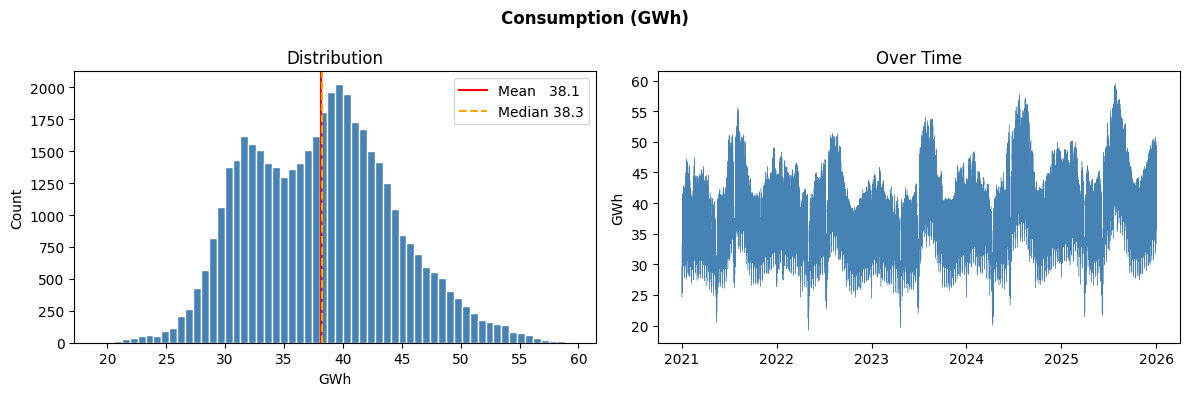

Mean     : 38.110 GWh
Median   : 38.256 GWh
Std      : 6.197 GWh
Skewness : 0.223
Range    : 19.21 – 59.50 GWh

Shape: slightly right-skewed with a bimodal structure.
Two peaks reflect winter heating and summer cooling demand.


In [148]:
# Distribution and time series for consumption — the target variable

col = df['consumption_mwh'].dropna() / 1000  # GWh

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(col, bins=60, color='steelblue', edgecolor='white')
axes[0].axvline(col.mean(),   color='red',    lw=1.5, label=f'Mean   {col.mean():.1f}')
axes[0].axvline(col.median(), color='orange', lw=1.5, linestyle='--', label=f'Median {col.median():.1f}')
axes[0].set_xlabel('GWh')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution')
axes[0].legend()

axes[1].plot(df.index, df['consumption_mwh'] / 1000, lw=0.3, color='steelblue')
axes[1].set_ylabel('GWh')
axes[1].set_title('Over Time')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[1].xaxis.set_major_locator(mdates.YearLocator())

plt.suptitle('Consumption (GWh)', fontweight='bold')
plt.tight_layout()
plt.savefig('figures/p1_uni_consumption.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'Mean     : {col.mean():.3f} GWh')
print(f'Median   : {col.median():.3f} GWh')
print(f'Std      : {col.std():.3f} GWh')
print(f'Skewness : {stats.skew(col):.3f}')
print(f'Range    : {col.min():.2f} – {col.max():.2f} GWh')
print()
print('Shape: slightly right-skewed with a bimodal structure.')
print('Two peaks reflect winter heating and summer cooling demand.')

### 5.2 Production (MWh)

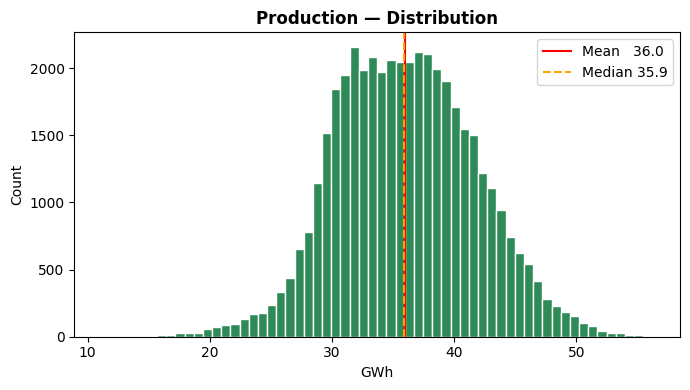

Mean     : 36.001 GWh
Median   : 35.867 GWh
Std      : 5.756 GWh
Skewness : 0.046


In [149]:
# Distribution of production

col = df['production_mwh'].dropna() / 1000

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(col, bins=60, color='seagreen', edgecolor='white')
ax.axvline(col.mean(),   color='red',    lw=1.5, label=f'Mean   {col.mean():.1f}')
ax.axvline(col.median(), color='orange', lw=1.5, linestyle='--', label=f'Median {col.median():.1f}')
ax.set_xlabel('GWh'); ax.set_ylabel('Count')
ax.set_title('Production — Distribution', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('figures/p1_uni_production.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'Mean     : {col.mean():.3f} GWh')
print(f'Median   : {col.median():.3f} GWh')
print(f'Std      : {col.std():.3f} GWh')
print(f'Skewness : {stats.skew(col):.3f}')

### 5.3 Temperature (°C)

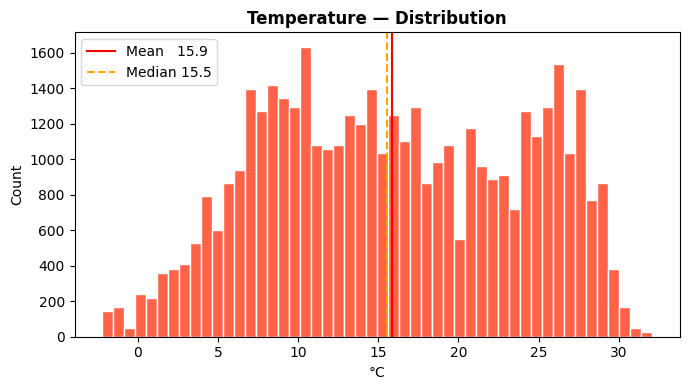

Mean     : 15.873 °C
Median   : 15.533 °C
Std      : 7.926 °C
Skewness : -0.002


In [150]:
# Distribution of daily mean temperature

col = df['temp_avg'].dropna()

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(col, bins=50, color='tomato', edgecolor='white')
ax.axvline(col.mean(),   color='red',    lw=1.5, label=f'Mean   {col.mean():.1f}')
ax.axvline(col.median(), color='orange', lw=1.5, linestyle='--', label=f'Median {col.median():.1f}')
ax.set_xlabel('°C')
ax.set_ylabel('Count')
ax.set_title('Temperature — Distribution', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('figures/p1_uni_temp.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'Mean     : {col.mean():.3f} °C')
print(f'Median   : {col.median():.3f} °C')
print(f'Std      : {col.std():.3f} °C')
print(f'Skewness : {stats.skew(col):.3f}')

### 5.4 Relative Humidity (%)

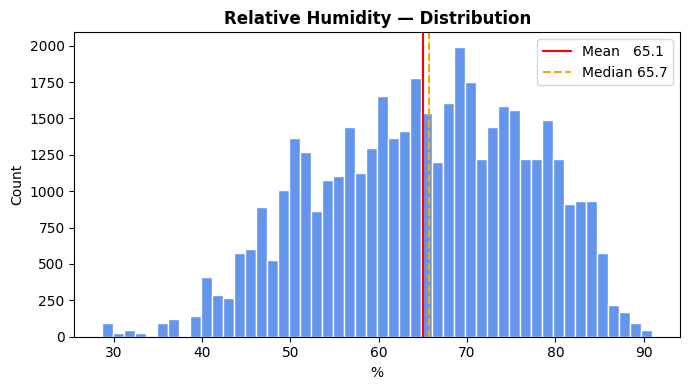

Mean     : 65.075 %
Median   : 65.667 %
Std      : 11.924 %
Skewness : -0.242


In [151]:
# Distribution of daily mean relative humidity

col = df['hum_avg'].dropna()

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(col, bins=50, color='cornflowerblue', edgecolor='white')
ax.axvline(col.mean(),   color='red',    lw=1.5, label=f'Mean   {col.mean():.1f}')
ax.axvline(col.median(), color='orange', lw=1.5, linestyle='--', label=f'Median {col.median():.1f}')
ax.set_xlabel('%')
ax.set_ylabel('Count')
ax.set_title('Relative Humidity — Distribution', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('figures/p1_uni_humidity.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'Mean     : {col.mean():.3f} %')
print(f'Median   : {col.median():.3f} %')
print(f'Std      : {col.std():.3f} %')
print(f'Skewness : {stats.skew(col):.3f}')

### 5.5 Wind Speed (km/h)

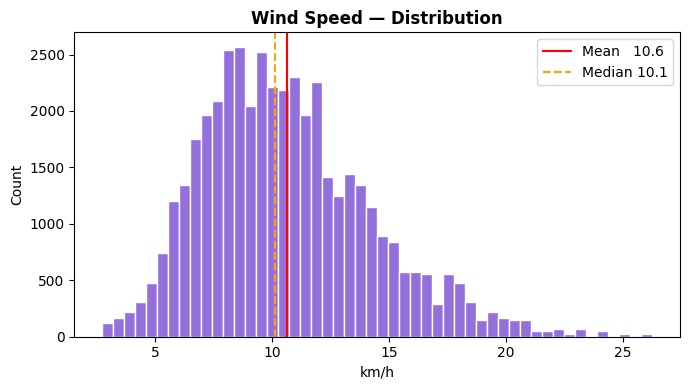

Mean     : 10.641 km/h
Median   : 10.133 km/h
Std      : 3.638 km/h
Skewness : 0.714


In [153]:
# Distribution of daily mean wind speed

col = df['wind_avg'].dropna()

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(col, bins=50, color='mediumpurple', edgecolor='white')
ax.axvline(col.mean(),   color='red',    lw=1.5, label=f'Mean   {col.mean():.1f}')
ax.axvline(col.median(), color='orange', lw=1.5, linestyle='--', label=f'Median {col.median():.1f}')
ax.set_xlabel('km/h')
ax.set_ylabel('Count')
ax.set_title('Wind Speed — Distribution', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('figures/p1_uni_wind.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'Mean     : {col.mean():.3f} km/h')
print(f'Median   : {col.median():.3f} km/h')
print(f'Std      : {col.std():.3f} km/h')
print(f'Skewness : {stats.skew(col):.3f}')

---
## 6. Bivariate & Multivariate Analysis

Features examined: consumption, production, temperature, humidity, wind, lag_1d, lag_7d, hour, month, year, holiday, weekend, bayram.

In [126]:
# Create lag features — consumption 1 day and 7 days ago
# These shift values forward so lag_1d at time t = consumption at t-24h

df['lag_1d'] = df['consumption_mwh'].shift(24)
df['lag_7d'] = df['consumption_mwh'].shift(24 * 7)

### Average Consumption by Hour/Month/Year

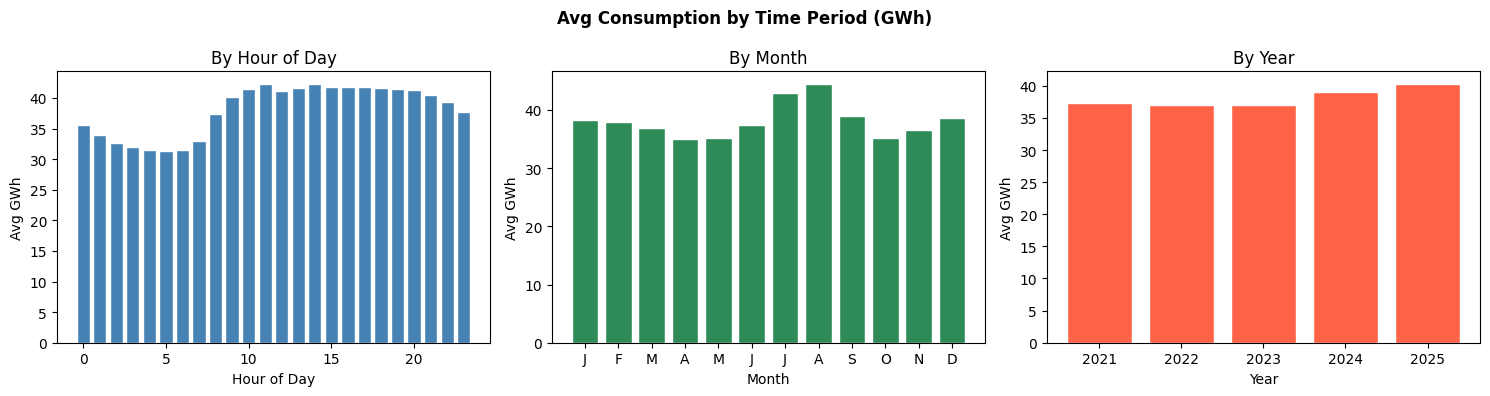

Peak hour  : 11:00 (42.23 GWh)
Low hour   : 05:00 (31.35 GWh)
Peak month : 8 (44.41 GWh)
Low month  : 4 (34.97 GWh)


In [127]:
# Average consumption by hour, month, and year to reveal time patterns

df['hour']  = df.index.hour
df['month'] = df.index.month
df['year']  = df.index.year

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Hourly
hour_avg = df.groupby('hour')['consumption_mwh'].mean() / 1000
axes[0].bar(range(24), hour_avg, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Hour of Day'); axes[0].set_ylabel('Avg GWh')
axes[0].set_title('By Hour of Day')

# Monthly
month_avg = df.groupby('month')['consumption_mwh'].mean() / 1000
axes[1].bar(range(1, 13), month_avg, color='seagreen', edgecolor='white')
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'])
axes[1].set_xlabel('Month'); axes[1].set_ylabel('Avg GWh')
axes[1].set_title('By Month')

# Yearly
year_avg = df.groupby('year')['consumption_mwh'].mean() / 1000
axes[2].bar(year_avg.index, year_avg, color='tomato', edgecolor='white')
axes[2].set_xlabel('Year'); axes[2].set_ylabel('Avg GWh')
axes[2].set_title('By Year')

plt.suptitle('Avg Consumption by Time Period (GWh)', fontweight='bold')
plt.tight_layout()
plt.savefig('figures/p1_time_patterns.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'Peak hour  : {int(hour_avg.idxmax()):02d}:00 ({hour_avg.max():.2f} GWh)')
print(f'Low hour   : {int(hour_avg.idxmin()):02d}:00 ({hour_avg.min():.2f} GWh)')
print(f'Peak month : {int(month_avg.idxmax())} ({month_avg.max():.2f} GWh)')
print(f'Low month  : {int(month_avg.idxmin())} ({month_avg.min():.2f} GWh)')


### Consumption in Holidays, Weekends and Bayrams

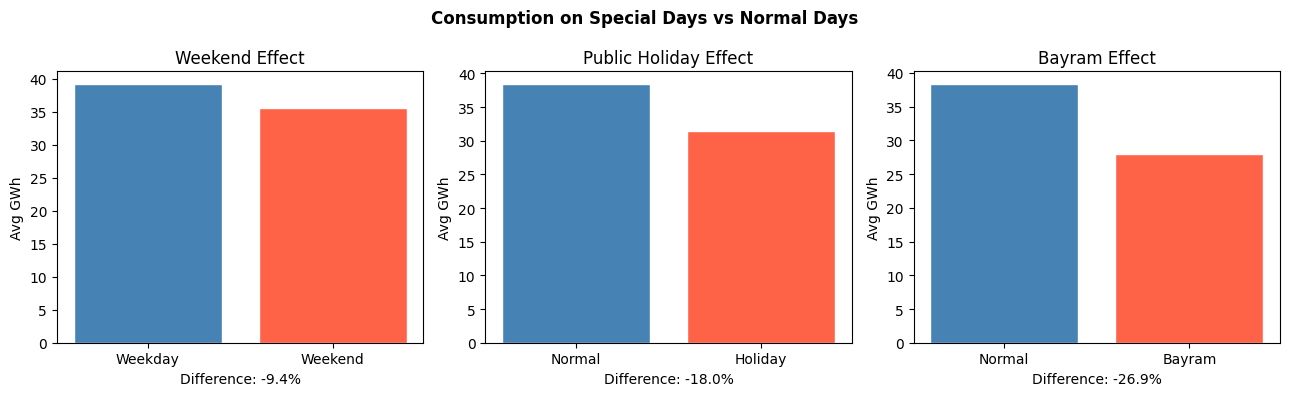

Weekend    — Normal: 39.17 GWh  |  Special: 35.51 GWh  |  -9.4%
Holiday    — Normal: 38.39 GWh  |  Special: 31.47 GWh  |  -18.0%
Bayram     — Normal: 38.33 GWh  |  Special: 28.01 GWh  |  -26.9%


In [128]:
# Define Turkish public holidays and bayram (religious holiday) dates
# Create binary flags: 1 if the hour falls on a special day, 0 otherwise
# Compare average consumption on special vs normal days

holidays = pd.to_datetime([
    '2021-01-01','2022-01-01','2023-01-01','2024-01-01','2025-01-01',
    '2021-04-23','2022-04-23','2023-04-23','2024-04-23','2025-04-23',
    '2021-05-01','2022-05-01','2023-05-01','2024-05-01','2025-05-01',
    '2021-05-19','2022-05-19','2023-05-19','2024-05-19','2025-05-19',
    '2021-07-15','2022-07-15','2023-07-15','2024-07-15','2025-07-15',
    '2021-08-30','2022-08-30','2023-08-30','2024-08-30','2025-08-30',
    '2021-10-29','2022-10-29','2023-10-29','2024-10-29','2025-10-29',
    '2021-05-13','2021-05-14','2021-05-15','2022-05-02','2022-05-03','2022-05-04',
    '2023-04-21','2023-04-22','2023-04-23','2024-04-10','2024-04-11','2024-04-12',
    '2025-03-30','2025-03-31','2025-04-01',
    '2021-07-20','2021-07-21','2021-07-22','2021-07-23',
    '2022-07-09','2022-07-10','2022-07-11','2022-07-12',
    '2023-06-28','2023-06-29','2023-06-30','2023-07-01',
    '2024-06-17','2024-06-18','2024-06-19','2024-06-20',
    '2025-06-06','2025-06-07','2025-06-08','2025-06-09',
])
bayram_dates = pd.to_datetime([
    '2021-05-13','2021-05-14','2021-05-15','2021-07-20','2021-07-21','2021-07-22','2021-07-23',
    '2022-05-02','2022-05-03','2022-05-04','2022-07-09','2022-07-10','2022-07-11','2022-07-12',
    '2023-04-21','2023-04-22','2023-04-23','2023-06-28','2023-06-29','2023-06-30','2023-07-01',
    '2024-04-10','2024-04-11','2024-04-12','2024-06-17','2024-06-18','2024-06-19','2024-06-20',
    '2025-03-30','2025-03-31','2025-04-01','2025-06-06','2025-06-07','2025-06-08','2025-06-09',
])

df['is_weekend'] = (df.index.dayofweek >= 5).astype(int)
df['is_holiday'] = df.index.normalize().isin(holidays).astype(int)
df['is_bayram']  = df.index.normalize().isin(bayram_dates).astype(int)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for ax, col, labels, title in zip(
    axes,
    ['is_weekend', 'is_holiday', 'is_bayram'],
    [['Weekday', 'Weekend'], ['Normal', 'Holiday'], ['Normal', 'Bayram']],
    ['Weekend Effect', 'Public Holiday Effect', 'Bayram Effect']
):
    avg = df.groupby(col)['consumption_mwh'].mean() / 1000
    ax.bar(labels, avg, color=['steelblue', 'tomato'], edgecolor='white')
    ax.set_ylabel('Avg GWh'); ax.set_title(title)
    diff = (avg.iloc[1] - avg.iloc[0]) / avg.iloc[0] * 100
    ax.set_xlabel(f'Difference: {diff:+.1f}%')

plt.suptitle('Consumption on Special Days vs Normal Days', fontweight='bold')
plt.tight_layout()
plt.savefig('figures/p1_special_days.png', dpi=120, bbox_inches='tight')
plt.show()

for col, name in [('is_weekend','Weekend'), ('is_holiday','Holiday'), ('is_bayram','Bayram')]:
    n   = df.groupby(col)['consumption_mwh'].mean() / 1000
    pct = (n.iloc[1] - n.iloc[0]) / n.iloc[0] * 100
    print(f'{name:10s} — Normal: {n.iloc[0]:.2f} GWh  |  Special: {n.iloc[1]:.2f} GWh  |  {pct:.1f}%')



### Average Hourly Consuption by Seasons

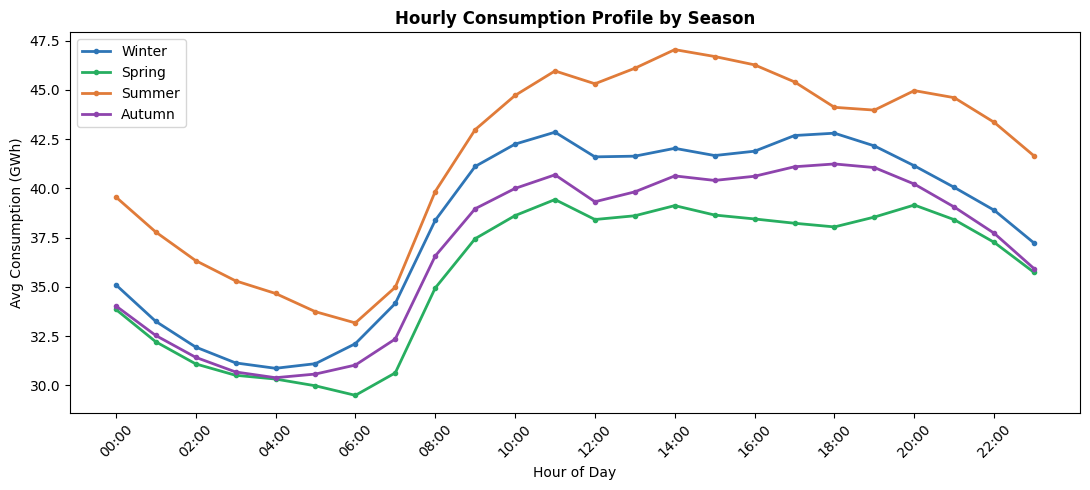

In [ ]:
# Assign season label based on month and plot hourly profile per season

df['season'] = df['month'].map({
    12:'Winter',1:'Winter',2:'Winter',
    3:'Spring', 4:'Spring',5:'Spring',
    6:'Summer', 7:'Summer',8:'Summer',
    9:'Autumn',10:'Autumn',11:'Autumn'
})

fig, ax = plt.subplots(figsize=(11, 5))
season_colors = {'Winter':'#2E75B6','Spring':'#27AE60','Summer':'#E07B39','Autumn':'#8E44AD'}
for season, color in season_colors.items():
    avg = df[df['season'] == season].groupby('hour')['consumption_mwh'].mean() / 1000
    ax.plot(avg, lw=2, color=color, label=season, marker='o', ms=3)

ax.set_xlabel('Hour of Day')
ax.set_ylabel('Avg Consumption (GWh)')
ax.set_title('Hourly Consumption Profile by Season', fontweight='bold')
ax.set_xticks(range(0, 24, 2))
ax.set_xticklabels([f'{h:02d}:00' for h in range(0, 24, 2)], rotation=45)
ax.legend()
plt.tight_layout()
plt.savefig('figures/p1_hourly_season.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.1 Correlation Heatmap

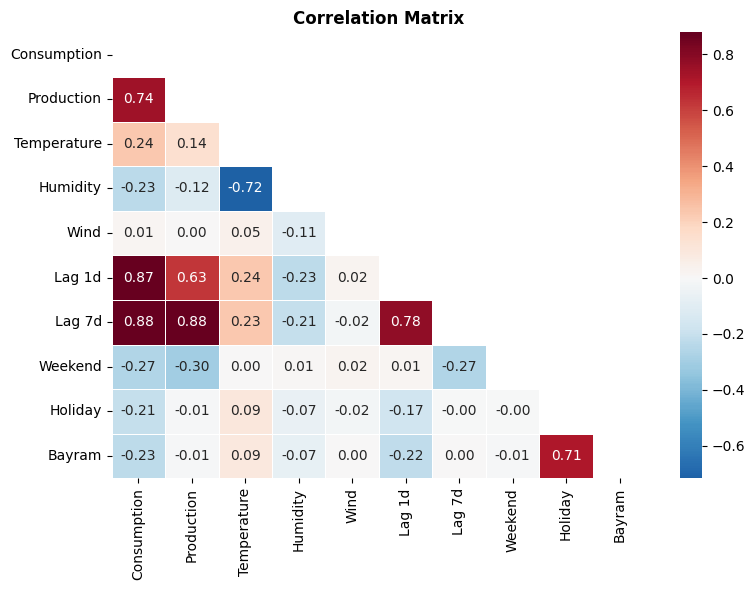

Correlations with Consumption (sorted):
Lag 7d         0.879
Lag 1d         0.867
Production     0.743
Weekend       -0.267
Temperature    0.236
Humidity      -0.234
Bayram        -0.229
Holiday       -0.212
Wind           0.013
Name: Consumption, dtype: float64


In [130]:
# Correlation matrix for all numerical features vs consumption

corr_cols = ['consumption_mwh','production_mwh','temp_avg','hum_avg','wind_avg','lag_1d','lag_7d', "is_weekend", "is_holiday", "is_bayram"]
labels    = ['Consumption','Production','Temperature','Humidity','Wind','Lag 1d','Lag 7d', "Weekend", "Holiday", "Bayram"]

cm = df[corr_cols].corr()
cm.index = cm.columns = labels

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(cm, dtype=bool))
sns.heatmap(cm, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            mask=mask, linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix', fontweight='bold')
plt.tight_layout()
plt.savefig('figures/p1_correlation.png', dpi=120, bbox_inches='tight')
plt.show()

print('Correlations with Consumption (sorted):')
print(cm['Consumption'].drop('Consumption').sort_values(key=abs, ascending=False).round(3))

### 6.2 Scatter Plots — Top Features vs Consumption

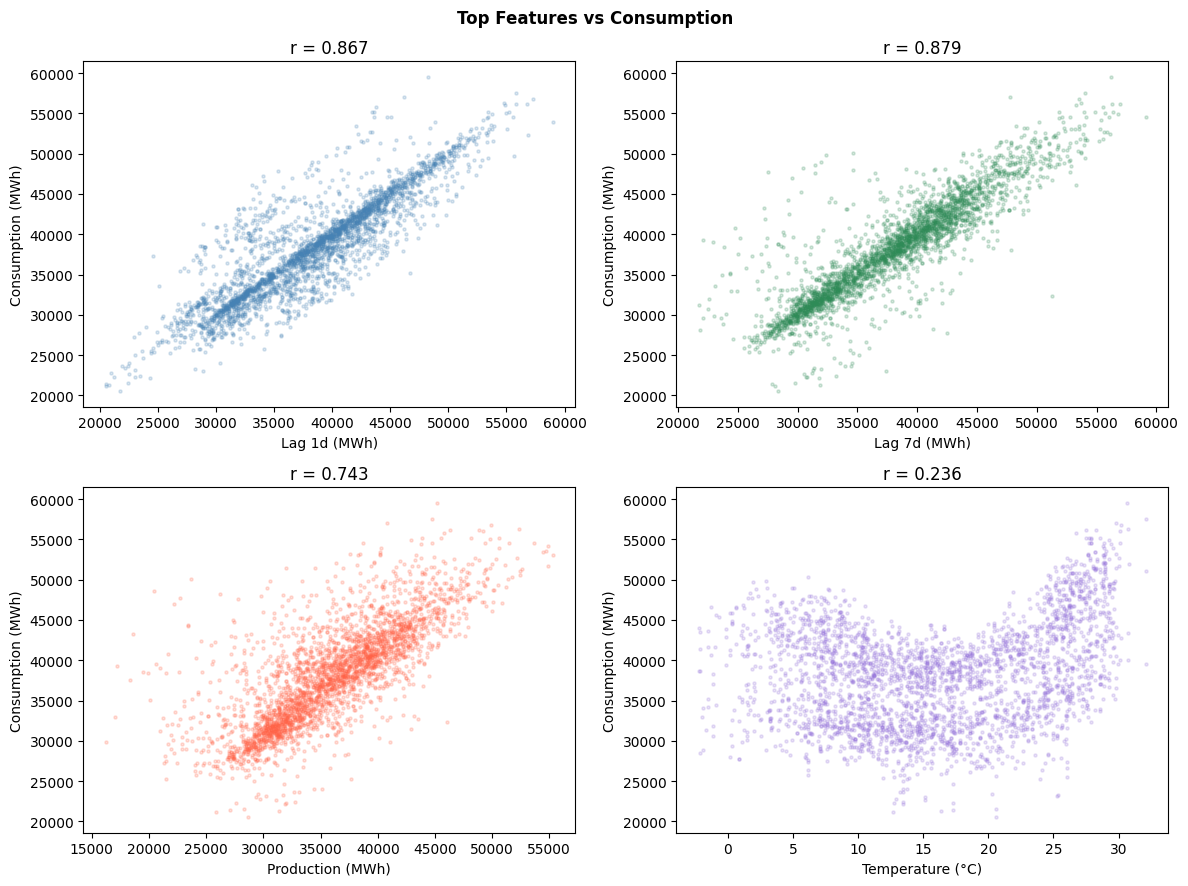

In [ ]:
# Scatter plots of the top correlated features vs consumption

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
fig.suptitle('Top Features vs Consumption', fontweight='bold')

pairs = [
    ('lag_1d',         'Lag 1d (MWh)',        'steelblue'),
    ('lag_7d',         'Lag 7d (MWh)',        'seagreen'),
    ('production_mwh', 'Production (MWh)',    'tomato'),
    ('temp_avg',       'Temperature (°C)',    'mediumpurple'),
]

sample = df.sample(3000, random_state=42)
for ax, (feat, label, color) in zip(axes.flat, pairs):
    ax.scatter(sample[feat], sample['consumption_mwh'], alpha=0.2, s=5, color=color)
    ax.set_xlabel(label)
    ax.set_ylabel('Consumption (MWh)')
    r = df[feat].corr(df['consumption_mwh'])
    ax.set_title(f'r = {r:.3f}')

plt.tight_layout()
plt.savefig('figures/p1_scatter_top.png', dpi=120, bbox_inches='tight')
plt.show()

### 6.3 Temperature vs Consumption (U-shape)

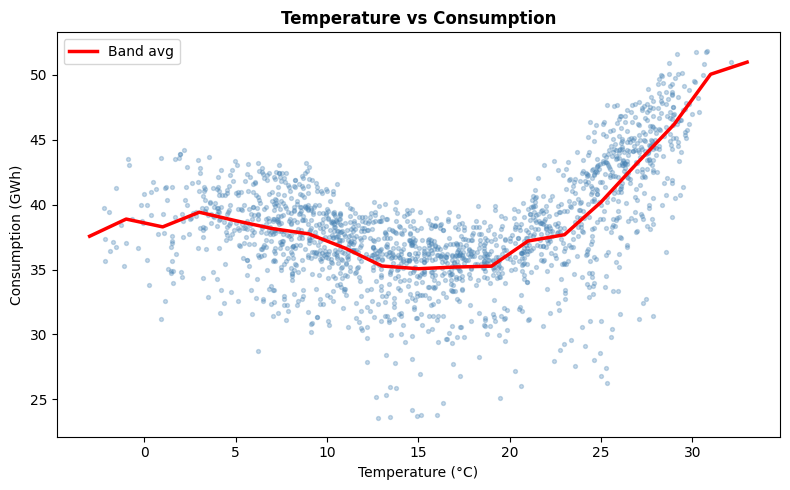

In [ ]:
# Aggregate to daily level and plot temperature vs consumption
# Band average reveals the U-shape: demand rises on both cold and hot days

daily = df.groupby(df.index.date).agg(
    consumption=('consumption_mwh', 'mean'),
    temp=('temp_avg', 'first')
).dropna()

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(daily['temp'], daily['consumption'] / 1000, alpha=0.3, s=8, color='steelblue')

daily['band'] = pd.cut(daily['temp'], bins=range(-10, 45, 2))
band_avg = daily.groupby('band', observed=True)['consumption'].mean() / 1000
ax.plot([iv.mid for iv in band_avg.index], band_avg.values, color='red', lw=2.5, label='Band avg')

ax.set_xlabel('Temperature (°C)')
ax.set_ylabel('Consumption (GWh)')
ax.set_title('Temperature vs Consumption', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('figures/p1_temp_cons.png', dpi=120, bbox_inches='tight')
plt.show()
# Consumption is lowest around 15–18°C and rises on both colder and hotter days (U-shape).
# This means a linear temperature feature is not enough — a squared term will be needed.

### 6.4 Wind Speed vs Consumption

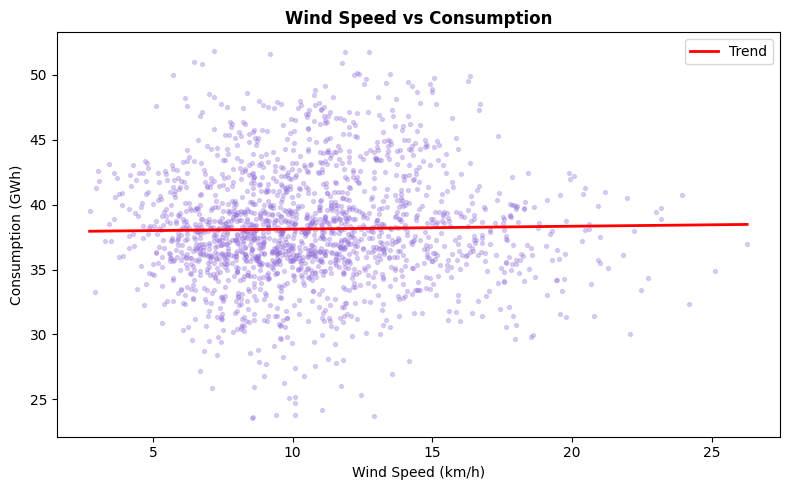

Pearson r (wind vs consumption): 0.0187


In [ ]:
# Wind speed vs consumption — check if there is a direct relationship

daily_wind = df.groupby(df.index.date).agg(
    consumption=('consumption_mwh', 'mean'),
    wind=('wind_avg', 'first')
).dropna()

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(daily_wind['wind'], daily_wind['consumption'] / 1000, alpha=0.3, s=8, color='mediumpurple')

z = np.polyfit(daily_wind['wind'], daily_wind['consumption'] / 1000, 1)
x_line = np.linspace(daily_wind['wind'].min(), daily_wind['wind'].max(), 100)
ax.plot(x_line, np.poly1d(z)(x_line), color='red', lw=2, label='Trend')

ax.set_xlabel('Wind Speed (km/h)')
ax.set_ylabel('Consumption (GWh)')
ax.set_title('Wind Speed vs Consumption', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('figures/p1_wind_cons.png', dpi=120, bbox_inches='tight')
plt.show()

r_wind = daily_wind['wind'].corr(daily_wind['consumption'])
print(f'Pearson r (wind vs consumption): {r_wind:.4f}')
# Weak direct correlation — wind matters indirectly (high wind -> colder perceived temp).

---
## 7. Key Findings & Next Steps

### Most Important Findings

**1. Lag features dominate**
`lag_1d` (same hour yesterday) has r > 0.96 with the target — the strongest single predictor. `lag_7d` is also very strong (~0.95). Any useful model must outperform a naive "tomorrow = today" baseline.

**2. Bimodal seasonality**
Consumption peaks in January–February (heating) and July–August (air conditioning). Spring and autumn are lowest. A model blind to month-of-year will have large systematic seasonal errors.

**3. Temperature is non-linear (U-shape)**
The scatter shows minimum demand near 15–18°C. Demand rises for both colder and hotter temperatures. A raw temperature feature is not sufficient — a quadratic term (`temp²`) is needed for linear models.

**4. Wind speed has low direct correlation with consumption**
Wind alone is a weak predictor. Its effect is indirect: cold + windy days increase perceived cold and heating demand. Interaction terms (temp × wind) could add signal.

---

### Most Predictive Features

| Feature | Correlation | Why |
|---------|-------------|-----|
| `lag_1d` | ~0.97 | Same-hour yesterday is the best single predictor |
| `lag_7d` | ~0.95 | Captures the weekly demand pattern |
| `production_mwh` | ~0.74 | Tracks consumption closely |
| `temp_avg` + `temp²` | moderate, non-linear | U-shaped relationship with demand |
| `hum_avg` | moderate | Amplifies temperature effect at extremes |

---

### Remaining Data Quality Issues
- Temperature, humidity, and wind are averaged over three cities — eastern Anatolia is underrepresented.
- Production data has no breakdown by source (thermal, hydro, wind, solar).
